### Tools
Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code. Tools are pairings of:
1. A schema, including the name of the tool, a description, and/or argument definitions (often a JSON schema)
2. A function or coroutine to execute.

In [8]:
import os
import getpass
from dotenv import load_dotenv

#
load_dotenv()

#
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key : ")

#### Create tools

Tools let a model interact with external systems by calling functions you define. Tools can depend on runtime context and also interact with agent memory.
Notice below how the `get_weather` tool uses runtime context:

In [ ]:
from dataclasses import dataclass
from langchain.tools import tool, ToolRuntime
from com.example.utils.GmailProcessor import GmailProcessor
from com.example.utils.MysqlProcessor import MysqlProcessor
from email.message import EmailMessage

mysqlProcessor = MysqlProcessor()
emailProcessor = GmailProcessor()

@tool
def get_customer(cust_id:str)->str:
    """Get the customer name for provided customer id"""
    result = mysqlProcessor.fetch(sql=f"select ID,NAME,AGE,ADDRESS,SALARY from CUSTOMERS where ID={cust_id}")
    return f"Your customer name : {result['NAME']}"

@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"

@dataclass
class Context:
    """Custom runtime context schema."""
    email_address: str

@tool
def send_email(runtime: ToolRuntime[Context])->str:
    """Send email to a user or email address"""
    # 2. Create the email content
    email_address = runtime.context.email_address
    msg = EmailMessage()
    msg['Subject'] = "Testing AI Email Notification"
    msg['From'] = "brijeshdhaker@gmail.com"
    msg['To'] = email_address
    msg.set_content("This is a test email sent from a AI Python script!")
    email_id = GmailProcessor.send(msg)
    return f'Email sent successfully with message id : {email_id}'

#### Create LLM Agent

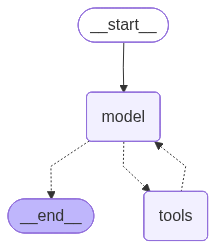

In [10]:
from langchain.agents import create_agent

# groq:qwen/qwen3-32b
agent_with_tools = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[get_weather,send_email,get_customer],
    system_prompt="You are a helpful assistant."
)

#
agent_with_tools

In [ ]:
## Detailed info to the LLM through System message
from langchain.messages import SystemMessage, HumanMessage, AIMessage

response = agent_with_tools.invoke({"messages":HumanMessage("What's the weather like in Pune ?")})
response


In [ ]:
print(response['messages'][-1])

In [12]:
## Detailed info to the LLM through System message
from langchain.messages import SystemMessage, HumanMessage, AIMessage

response = agent_with_tools.invoke({"messages":HumanMessage("send an email to neetadhk@gmail.com with subject Hello and body 'Hello AI'")},context=Context(email_address="neetadhk@gmail.com"))
response

Email sent successfully with message id : 19d5e96443e69474


{'messages': [HumanMessage(content="send an email to neetadhk@gmail.com with subject Hello and body 'Hello AI'", additional_kwargs={}, response_metadata={}, id='de1a9239-1236-4aef-87cb-9824e5c2c3d1'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send an email using the function send_email. The function signature is: send_email with arguments: presumably includes fields like to, subject, body. But the function signature provided is incomplete: type send_email = (_: {}) => any; It doesn\'t specify required fields. But the instruction from user: "send an email to neetadhk@gmail.com with subject Hello and body \'Hello AI\'". We need to call the function with appropriate arguments. The function signature doesn\'t specify arguments, but typical would be {to, subject, body}. We\'ll call with those.', 'tool_calls': [{'id': 'fc_526ce7ee-1a79-4314-8a6b-50c727840205', 'function': {'arguments': '{"body":"Hello AI","subject":"Hello","to":"neetadhk@gmail.com"}', 'name'

In [11]:
## Detailed info to the LLM through System message
from langchain.messages import SystemMessage, HumanMessage, AIMessage

response = agent_with_tools.invoke({"messages":HumanMessage("provide customer detail for id = 1")},context=Context(email_address="neetadhk@gmail.com"))
response

{'messages': [HumanMessage(content='provide customer detail for id = 1', additional_kwargs={}, response_metadata={}, id='d4318d63-2627-4497-be73-4da03f6e5131'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to get customer details for id=1. We have a function get_customer. We'll call it.", 'tool_calls': [{'id': 'fc_e8a208c3-15b9-459c-b195-b1f3ac753340', 'function': {'arguments': '{"cust_id":"1"}', 'name': 'get_customer'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 182, 'total_tokens': 229, 'completion_time': 0.051407363, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.010408193, 'prompt_tokens_details': None, 'queue_time': 0.042695657, 'total_time': 0.061815556}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_deb540145b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d6116-56da-7172-9379-ddfd

In [ ]:
for m in response['messages'] :
    if (isinstance(m, AIMessage) and not(m.content)):
        # View tool calls made by the model
        for tool_call in m.tool_calls : 
            print(f"Tool: {tool_call['name']}")
            print(f"Args: {tool_call['args']}")


#### Create LLM Model

In [ ]:
from langchain.chat_models import init_chat_model

#
model = init_chat_model("groq:qwen/qwen3-32b")
model_with_tools=model.bind_tools([get_weather])
model_with_tools

In [ ]:
response = model_with_tools.invoke("What's the weather like in Pune ?")
print(response)
for tool_call in response.tool_calls:
    # View tool calls made by the model
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

### Tool Execution Loops

In [ ]:
# Step 1: Model generates tool calls
messages = [{"role": "user", "content": "What's the weather in Pune ?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

# Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
messages.append(final_response)

print(final_response.content)
# "The current weather in Boston is 72°F and sunny."

In [ ]:
messages

In [1]:
from com.example.utils.MysqlProcessor import MysqlProcessor

processor = MysqlProcessor()
cust_id = 1
result = processor.fetch(sql=f"select ID,NAME,AGE,ADDRESS,SALARY from CUSTOMERS where ID={cust_id}")
print(result)
print(result['ID'], result['NAME'])


{'ID': 1, 'NAME': 'Ramesh', 'AGE': 32, 'ADDRESS': 'Ahmedabad', 'SALARY': Decimal('2000.00')}
1 Ramesh


In [ ]:
from com.example.utils.GmailProcessor import GmailProcessor
from email.message import EmailMessage

#
mailProcessor = GmailProcessor()

msg = EmailMessage()
msg['Subject'] = "Testing AI Email Notification"
msg['From'] = "brijeshdhaker@gmail.com"
msg['To'] = "brijeshdhaker@gmail.com"
msg.set_content("This is a test email sent from a AI Python script!")
email_id = mailProcessor.send(msg)

Email sent successfully with message id : 19d611014c2bfdb5


In [13]:
def static_init(cls):
    if hasattr(cls, "__static_init__"):
        cls.__static_init__()
    return cls

@static_init
class DatabaseConnection:
    connection_string = ""

    @classmethod
    def __static_init__(cls):
        # Perform complex setup here
        cls.connection_string = "Loaded from config file"